In [ ]:
import numpy as np 
import pandas as pd 

df= pd.read_csv("IMDB Dataset.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [100]:
df["review"][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

## Imports, Data Loading, and Sampling

In [101]:
# Sample 50,000 rows
df_sampled = df.sample(n=50000, random_state=42).reset_index(drop=True)

In [102]:
df_sampled['review'].iloc[0][:300]

"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok "

In [103]:
df_sampled.shape

(50000, 2)

## Remove HTML Tags 

In [104]:
#   Remove html tags

from bs4 import BeautifulSoup

def remove_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

# Apply Step 2
df_sampled['no_html'] = df_sampled['review'].apply(remove_html)

In [105]:
df_sampled['no_html'].iloc[0][:200]

"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ev"

## Convert Into lower case

In [106]:
# convert into lower case
def to_lowercase(text):
    return text.lower()

# Apply Step 4
df_sampled['lowercase'] = df_sampled['no_html'].apply(to_lowercase)


In [107]:
print(df_sampled['lowercase'].iloc[0][:200])

i really liked this summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. anyways, this could have been one of the best summerslam's ev


## Remove Special Characters

In [108]:
#   lowercase letters aur spaces allow 
import re
def remove_special_characters(text):
        return re.sub(r'[^a-z\s]', '', text)

# Apply Step 3
df_sampled['no_special'] = df_sampled['lowercase'].apply(remove_special_characters)

In [109]:
print(df_sampled['no_special'].iloc[0][:200])

i really liked this summerslam due to the look of the arena the curtains and just the look overall was interesting to me for some reason anyways this could have been one of the best summerslams ever i


## Removing Stop Words

In [110]:
# Load standard stop words
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Important negation words safe  
negation_words = {'not', 'no', 'never', 'neither', 'nor', 'but', 'however', 
                  'didnt', 'wasnt', 'couldnt', 'wouldnt', 'shouldnt', 'werent'}
stop_words = stop_words - negation_words

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

# Apply Step 5
df_sampled['no_stopwords'] = df_sampled['no_special'].apply(remove_stopwords)

In [111]:
print(df_sampled['no_stopwords'].iloc[0][:200])

really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslams ever wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man but i


## Stemming

In [112]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def apply_stemming(text):
    words = text.split()
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

# Apply Step 6
df_sampled['final_cleaned_review'] = df_sampled['no_stopwords'].apply(apply_stemming)

 

In [113]:
df_sampled['final_cleaned_review'].iloc[0][:200]

'realli like summerslam due look arena curtain look overal interest reason anyway could one best summerslam ever wwf didnt lex luger main event yokozuna time ok huge fat man vs strong man but im glad t'

## Feature Extraction (TF-IDF Vectorization)

In [128]:

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), sublinear_tf=True)

# 2. Text to numbers (matrix)  transformation
X = tfidf.fit_transform(df_sampled['final_cleaned_review']).toarray()

# 3. Target variable (Sentiments)
y = df_sampled['sentiment']


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [129]:
print(f"Features Matrix Shape (Rows, Unique Words): {X.shape}")
print(f"Target Array Shape: {y.shape}")

Features Matrix Shape (Rows, Unique Words): (50000, 15000)
Target Array Shape: (50000,)


In [116]:
X[0].mean()

np.float64(0.0054971530814936385)

## Train-Test Split

In [130]:
from sklearn.model_selection import train_test_split

# Data split  (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

 


## Train Naive Bayes 3 Models

In [132]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB


# 1. models initialize 
clf1= MultinomialNB(alpha=0.5)
clf2= BernoulliNB(alpha=0.5)
clf3= GaussianNB()



In [133]:
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)
clf3.fit(X_train, y_train)

GaussianNB()

In [137]:
# Predictions nikalna
y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)
y_pred3 = clf3.predict(X_test)
 

## check Accuracy_Score of 3 models

In [135]:
from sklearn.metrics import accuracy_score
print(f"Multinomial NB Accuracy : {accuracy_score(y_test, y_pred1)}%")
print(f"Bernoulli NB Accuracy : {accuracy_score(y_test, y_pred2)}%")
print(f"GaussianNB Accuracy : {accuracy_score(y_test, y_pred3)}%")

Multinomial NB Accuracy : 0.8734%
Bernoulli NB Accuracy : 0.8647%
GaussianNB Accuracy : 0.8463%


In [145]:
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix
)

# Model Evaluation Helper Function (Auto-detects string labels like 'positive')
def display_model_metrics(model_name, y_true, y_pred):
 
    print(f" ADVANCED METRICS FOR: {model_name}")
     
    pos_lbl = 'positive' if 'positive' in y_true.values else 1
    
    print(f"Accuracy  : {accuracy_score(y_true, y_pred) * 100:.2f}%")
    print(f"Precision : {precision_score(y_true, y_pred, pos_label=pos_lbl) * 100:.2f}%")
    print(f"Recall    : {recall_score(y_true, y_pred, pos_label=pos_lbl) * 100:.2f}%")
    print(f"F1-Score  : {f1_score(y_true, y_pred, pos_label=pos_lbl) * 100:.2f}%")
    print(f"\n Detailed Classification Report:")
    print(classification_report(y_true, y_pred))
    print("\n")

display_model_metrics("Multinomial Naive Bayes", y_test, y_pred1)
display_model_metrics("Bernoulli Naive Bayes", y_test, y_pred2)
display_model_metrics("Gaussian Naive Bayes", y_test, y_pred3)


 ADVANCED METRICS FOR: Multinomial Naive Bayes
Accuracy  : 87.34%
Precision : 86.94%
Recall    : 87.88%
F1-Score  : 87.41%

 Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.87      0.87      5000
    positive       0.87      0.88      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



 ADVANCED METRICS FOR: Bernoulli Naive Bayes
Accuracy  : 86.47%
Precision : 85.58%
Recall    : 87.72%
F1-Score  : 86.64%

 Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.87      0.85      0.86      5000
    positive       0.86      0.88      0.87      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



 ADVANCED METRICS FOR: Gaussia

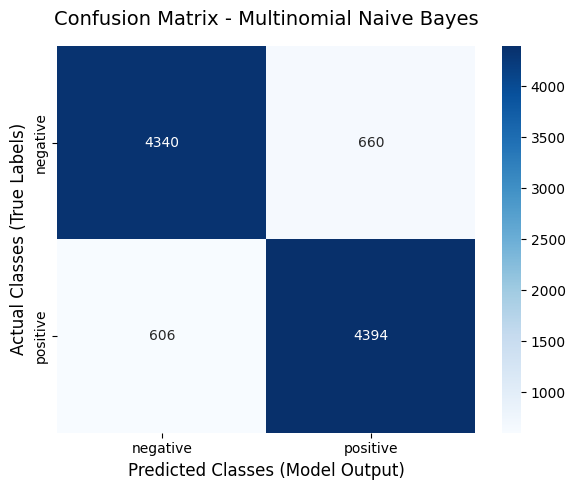

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate Confusion Matrix for our best model (MultinomialNB)
cm = confusion_matrix(y_test, y_pred1)
unique_labels = sorted(list(set(y_test)))

# Plotting the Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=unique_labels, 
            yticklabels=unique_labels)

plt.title('Confusion Matrix - Multinomial Naive Bayes', fontsize=14, pad=15)
plt.ylabel('Actual Classes (True Labels)', fontsize=12)
plt.xlabel('Predicted Classes (Model Output)', fontsize=12)
plt.tight_layout()
plt.show()

In [147]:

# Get all feature names (words) from our TF-IDF Vectorizer
feature_names = tfidf.get_feature_names_out()

# Get log probabilities of features given a class from MultinomialNB
 
neg_features_prob = clf1.feature_log_prob_[0]
pos_features_prob = clf1.feature_log_prob_[1]
 
top_neg_indices = np.argsort(neg_features_prob)[-10:]
top_pos_indices = np.argsort(pos_features_prob)[-10:]

top_neg_words = [feature_names[i] for i in top_neg_indices]
top_pos_words = [feature_names[i] for i in top_pos_indices]
 
top_words_df = pd.DataFrame({
    'Top Words for Negative Reviews ': top_neg_words[::-1], # [:: -1] reverses to show highest first
    'Top Words for Positive Reviews ': top_pos_words[::-1]
})
 
# 🎯 TOP WORDS INFLUENCING THE MODEL
print("🎯 TOP WORDS INFLUENCING THE MODEL") 
display(top_words_df)

🎯 TOP WORDS INFLUENCING THE MODEL


,Top Words for Negative Reviews,Top Words for Positive Reviews
0,movi,film
1,film,movi
2,but,but
3,not,one
4,like,not
5,one,great
6,bad,like
7,watch,see
8,no,love
9,even,good


# Save Cleansed Data & Export

In [ ]:
  
output_fields = ['final_cleaned_review', 'sentiment']
df_sampled[output_fields].to_csv('IMDB_Cleaned_Data_50K.csv', index=False)

print("✅ Success! Your 50K clean dataset has been saved as 'IMDB_Cleaned_Data_50K.csv' in the Kaggle working directory.")